# Machine Learning in Python - Project 2

*George Boutselis (s2162263), Maximillian McCourt (s2145762)*

## Setup

In [ ]:
# Data libraries
import json
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting defaults
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 80

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer, FunctionTransformer, OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score,classification_report, make_scorer
from sklearn.inspection import permutation_importance

# imblearn modules
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn import FunctionSampler
from imblearn.pipeline import Pipeline, make_pipeline

# Keras modules
import keras
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras import Model, regularizers
from keras.callbacks import EarlyStopping, LambdaCallback
from keras.optimizers import Adam

In [ ]:
# Load Freddie Mac data
d = pd.read_csv("freddiemac.csv", low_memory=False)
d.head()

,fico,dt_first_pi,flag_fthb,dt_matr,cd_msa,mi_pct,cnt_units,occpy_sts,cltv,dti,...,seller_name,servicer_name,flag_sc,id_loan_rr,program_ind,rr_ind,property_val,io_ind,mi_cancel_ind,loan_status
0,809,201705,N,204704,NaN,0,1,P,75,38,...,Other sellers,SPECIALIZED LOAN SERVICING LLC,NaN,NaN,9,NaN,2,N,7,prepaid
1,702,201703,N,203202,NaN,0,1,P,80,36,...,Other sellers,Other servicers,NaN,NaN,9,NaN,2,N,7,active
2,792,201703,N,204702,NaN,0,1,S,60,36,...,Other sellers,Other servicers,NaN,NaN,9,NaN,2,N,7,prepaid
3,776,201703,N,204702,NaN,0,1,S,80,18,...,Other sellers,Other servicers,NaN,NaN,9,NaN,2,N,7,prepaid
4,790,201703,N,204702,41620.0,0,1,I,75,42,...,Other sellers,"PNC BANK, NA",NaN,NaN,9,NaN,2,N,7,active


In [ ]:
# Feature types used for EDA/Feature Engineering
cat_features = ['flag_fthb', 'rr_ind', 'occpy_sts', 'prop_type', 'property_val', 'loan_purpose', 'servicer_name', 'flag_sc', 'seller_name', 'program_ind']
num_features = ['mi_pct', 'orig_loan_term', 'fico', 'cltv', 'int_rt', 'orig_upb', 'dti']
ord_features = ['cnt_borr', 'cnt_units']
geo_features = ['cd_msa', 'st']

In [ ]:
rng = 4

In [ ]:
# Load delinquency rates for MSA and states
del_msa_rates = pd.read_csv("MSA_Mortgages_90-plus-days-late.csv")
del_state_rates = pd.read_csv("State_Mortgages_90-plus-days-late.csv")

In [ ]:
del_msa_rates.head()

,RegionType,Name,CBSACode,2008-01,2008-02,2008-03,2008-04,2008-05,2008-06,2008-07,...,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06
0,National,United States,-----,1.5,1.6,1.6,1.5,1.6,1.7,1.8,...,0.5,0.6,0.6,0.6,0.7,0.6,0.6,0.6,0.6,0.6
1,MetroArea,"Akron, OH",10420,1.8,1.9,1.8,1.6,1.7,1.7,1.7,...,0.3,0.3,0.3,0.4,0.5,0.6,0.5,0.4,0.3,0.3
2,MetroArea,"Albany-Schenectady-Troy, NY",10580,1.0,1.1,1.0,1.0,1.1,1.0,1.2,...,0.6,0.7,0.6,0.7,0.8,0.7,0.7,0.7,0.6,0.6
3,MetroArea,"Albuquerque, NM",10740,1.2,1.1,1.1,1.1,1.3,1.3,1.3,...,0.6,0.6,0.6,0.8,0.8,0.7,0.6,0.5,0.6,0.6
4,MetroArea,"Allentown-Bethlehem-Easton, PA-NJ",10900,1.3,1.2,1.2,1.2,1.3,1.4,1.4,...,0.7,0.8,0.8,0.7,0.7,0.8,0.7,0.6,0.6,0.7


In [ ]:
del_state_rates.head()

,RegionType,Name,FIPSCode,2008-01,2008-02,2008-03,2008-04,2008-05,2008-06,2008-07,...,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06
0,National,United States,-----,1.5,1.6,1.6,1.5,1.6,1.7,1.8,...,0.5,0.6,0.6,0.6,0.7,0.6,0.6,0.6,0.6,0.6
1,State,AL,'01',1.4,1.4,1.4,1.4,1.4,1.5,1.6,...,0.7,0.7,0.8,0.8,0.8,0.8,0.7,0.7,0.7,0.8
2,State,AK,'02',0.6,0.8,0.8,0.7,0.9,1.0,1.1,...,0.6,0.5,0.5,0.6,0.5,0.7,0.6,0.5,0.5,0.5
3,State,AZ,'04',1.5,1.7,1.7,1.8,1.8,1.9,2.1,...,0.3,0.4,0.4,0.5,0.5,0.5,0.4,0.4,0.4,0.4
4,State,AR,'05',1.4,1.4,1.3,1.3,1.2,1.3,1.3,...,0.8,0.7,0.8,0.9,0.9,0.9,0.9,0.9,0.8,0.8


In [ ]:
rates = pd.read_csv('historicalweeklydata.csv')
rates.head()

,Week,30_yr_FRM,15_yr_FRM
0,16/04/1971,7.31,NaN
1,23/04/1971,7.31,NaN
2,30/04/1971,7.29,NaN
3,07/05/1971,7.38,NaN
4,14/05/1971,7.42,NaN


# Introduction

The prediction of mortgage defaults is a critical task in financial risk management, with wide-ranging implications for lending institutions, investors, and regulatory bodies. With Freddie Mac's growing interest in risk-sharing initiatives and transparency in mortgage performance, accurately modelling default risk has never been more important. This report investigates the credit performance of fully amortising, fixed-rate single-family mortgages purchased or guaranteed by Freddie Mac between 2017 and 2020, with the goal of developing a model that identifies loans at higher risk of default.

We construct a classification model that identifies between loans that have defaulted and those that have been prepaid, excluding active loans which remain unresolved at the performance cut-off date. The dataset includes borrower credit characteristics, property and loan features, and various categorical features based on geographical location, insurance details, and refinancing programmes. As mortgage defaults are relatively rare, a key challenge in this task is addressing the highly loan status data, as defaults are relatively rare compared to prepayments.

Our approach begins with data cleaning and exploration, followed by the development of a baseline model. We then implement feature engineering, including derived financial indicators and external rate data, to improve predictive performance. After training and validating our final model, we apply it to currently active loans to identify those with a high probability of future default.


## Introduction to the Dataset

This report uses a subset of Freddie Mac's Single Family Loan-Level Dataset [1], containing information on 200,000 fully amortising, fixed-rate single-family mortgages originated between 2017 and 2020. The dataset includes the following features:

- `fico` - A credit score summarising the borrower's creditworthiness at the time of acquisition and used to originate the mortgage. A higher credit score may indicate a higher likelihood that the borrower will timely repay future obligations. Consists of values between 300-850, with 9999 for non-available data (credit scores < 300 or > 850 are shown as not available).
- `flag fthb` - Indicates if the borrower is an individual who is purchasing the mortgaged property, will reside in the mortgaged property as a primary residence and had no ownership interest in a residential property during the the year-year period preceding the date of the purchase of the mortgaged property.Formmated as: Y=Yes, N=No, 9=Not Available/Not Applicable.
- `cd msa` - Lists Metropolitan Statistical Area or Metropolitan division code of which the mortgaged property is located in. Null entries indicate that the mortgaged property is in a non-metropolitan area or unknown.
- `mi pct` - The mortgage insurance percentage (MI %) of loss coverage on the loan, at the time of Freddie Mac’s purchase of the mortgage loan, that a mortgage insurer provides to cover losses incurred as a result of a default on the loan. MI percentages of less than 1% or greater than 55% are disclosed as "Not Available", taking value 999. No MI is indicated by zero.
- `cnt units` - Denotes whether the mortgage is a one-, two-, three-, or four-unit property, with 99 indicating Not Available.
- `occpy sts` - Denotes whether the mortgage type is owner occupied (P), second home (S), or investment property (I), or Not Available (9).
- `cltv` - Original combined loan-to-value (CLTV), with 999 indicating Not Available.
- `dti` - Original debt-to-income (DTI) ratio, based on the sum of the borrower's monthly debt payments (including monthly housing expenses that incorporate the mortgage payment the borrower is making at the time of the delivery of the mortgage loan to Freddie Mac) divided by the total monthly income (as of the date of the origination of the loan). Ratios greater than 65% are shown as Not Available, indiated with value 999.
- `orig upb` - The unpaid balance (UPB) of the mortgage on the note date (rounded to the nearest $1,000).
- `int rt` - The interest rate of the loan at the time the loan was originated.
- `st` - A two-letter abbreviation indicating the state or territory within which the property securing the mortgage is located.
- `prop type` - Denotes whether the property type secured by the mortgage is a condominium (CO), planned unit development (PU), cooperative share (CP), manufactured home (MH), or Single-Family home (SF). If the Property Type is Not Available, this is indicated by value 99.
- `id loan` - Unique identifier assigned to each loan.
- `loan purpose` - Indicates whether the mortgage loan is a Cash-out Refinance mortgage (C), No Cash-out Refinance mortgage (N), Refinance mortgage not specified (R), or a Purchase mortgage (P), with 9=Not Available.
- `orig loan term` - The number of scheduled monthly payments of the mortgage based on the First Payment Date and Maturity Date.
- `cnt borr` - The number of Borrower(s) who are obligated to repay the mortgage note secured by the mortgaged property.
- `seller name` - The name of the entity acting in its capacity as a seller of mortgages to Freddie Mac at the time of acquisition.
- `servicer name` - The name of the entity acting in its capacity as the servicer of mortgages to Freddie Mac as of the last period for which loan activity is reported in the Dataset.
- `flag sc` - Indicates if the mortgage exceeds conforming loan limits with origination dates on or after 10/1/2008 and were delivered to Freddie Mac on or after 1/1/2009. Formatted Y=Yes, N=NaN.
- `program ind` - Indicates if a loan participates in any of the programs: H = Home Possible, F = HFA Advantage, R= Refi Possible, 9= Not Available/Not Applicable.
- `rr ind` - Indicates if a loan is part of Freddie Mac’s Relief Refinance Program. Formatted Y=Yes and N=NaN.
- `property val` - Indicates which method was used to obtain a property appraisal. Values: 1 = ACE Loans, 2 = Full Appraisal, 3 = Other Appraisals (Desktop, driveby, external, AVM), 4=ACE+PDR, 9= Not Available.


# Exploratory Data Analysis and Feature Engineering

## Data Pre-Processing

### Splitting data into Training and Testing data

Given our ambition to construct a predictive model that provides insight into whether a loan will default, we set aside all data with active loans, to return to at the end of the report. For our model construction, we investigate all loans that have been prepaid or have defaulted. We take the response variable $y$ to be the binary indicator of whether a loan defaults; equalling $1$ for defaulted loans and $0$ for prepaid loans.

In [ ]:
# Splitting the data into active and not active loans
active_mask = (d['loan_status'] == 'active')
d_active = d[active_mask].copy()
d_not_active = d[~active_mask].copy()

features = list(set(d.columns).difference({'loan_status'}))
X = d_not_active[features].copy(); y = d_not_active['loan_status'].copy()
y = np.where(y == 'default', 1, 0)

To avoid data leakage and overfitting, we split this data into training (80%) and testing (20%) datasets and construct our model only using the training dataset. We also randomly split our data (while using a random seed for reproducibility) to eliminate the risk of some order bias in our data.

In [ ]:
# Dropping the active loans from the dataset, splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=rng, stratify=y)

Next, we aim to gather more information on the data. In particular, we wish to know the data-types of each variable, and investigate if there is any missing data. This is done with the intention of gaining insight into the pre-processing techniques that should be used on this dataset.

Our introduction of the dataset detailed various features displaying "9", "99", "999", or "9999" for non-available data. To investigate, we convert these non-available data into null entries, using the `missing_codes` dictionary and `UnifyTransformer` specified below.

In [ ]:
# Missing codes corresponding to each feature
missing_codes = {
    'fico': 9999,        # censored
    'mi_pct': 999,       # censored
    'program_ind': 9,    # censored
    'cltv': 999,         # numeric (not-censored)
    'property_val': 9,   # categorical (not-censored)
    'dti': 999           # numeric
}

In [ ]:
# Transformer to identify numerically-encoded missing data of each feature
class UnifyMissing(BaseEstimator, TransformerMixin):
    def __init__(self, missing_dict, fill_value=np.nan):
        self.missing_dict = missing_dict
        self.fill_value = fill_value

    def fit(self, X, y=None):
        # Store the input feature names in the standard attribute name.
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.tolist()
        else:
            self.feature_names_in_ = [f"x{i}" for i in range(X.shape[1])]
        return self


    def transform(self, X):
        # When transforming, ensure we output a DataFrame with the original column names.
        X_ = pd.DataFrame(X.copy(), columns=self.feature_names_in_)
        for col, code in self.missing_dict.items():
            if col in X_.columns:
                X_[col] = X_[col].replace(code, self.fill_value)
        return X_

    def get_feature_names_out(self, input_features=None):
        # Always return the stored original feature names.
        return np.array(self.feature_names_in_)


In [ ]:
# Applying missing data transformer to the training data
X_train_ = UnifyMissing(missing_codes).fit_transform(X_train)

In [ ]:
# Classifying X_train_ feature types and number of missing values
info_list = []
for col in X_train_.columns:
    dtype = X_train_[col].dtype
    non_na = X_train_[col].count()
    info_list.append(f"{col}({dtype}, non-null={non_na})")
print(", ".join(info_list))

# Checking the number of missing values of each observation
na_per_row = X_train_.isna().sum(axis=1)
print('\nValue counts of missing per row:')
for missing_count, freq in na_per_row.value_counts().items():
    print(f"{missing_count} missing values: {freq} rows")

servicer_name(object, non-null=101364), fico(float64, non-null=101346), rr_ind(object, non-null=1047), cnt_units(int64, non-null=101364), loan_purpose(object, non-null=101364), id_loan_rr(object, non-null=1047), dti(float64, non-null=100314), occpy_sts(object, non-null=101364), orig_loan_term(int64, non-null=101364), cd_msa(float64, non-null=92361), cltv(float64, non-null=101363), mi_pct(float64, non-null=101363), cnt_borr(int64, non-null=101364), program_ind(object, non-null=101364), int_rt(float64, non-null=101364), channel(object, non-null=101364), property_val(float64, non-null=101283), zipcode(int64, non-null=101364), prod_type(object, non-null=101364), ltv(int64, non-null=101364), io_ind(object, non-null=101364), prop_type(object, non-null=101364), flag_fthb(object, non-null=101364), seller_name(object, non-null=101364), ppmt_pnlty(object, non-null=101364), dt_matr(int64, non-null=101364), orig_upb(int64, non-null=101364), dt_first_pi(int64, non-null=101364), st(object, non-null=

Our dataset contains several features that, in raw form, are highly unlikely to provide any valuable insight into risk of the loan defaulting. In particular, `id loan` consists of unique loan identifications and will have no relationship with the response variable. Similarly, features such as `cd msa`, which provide geographical information about the location of the single-family mortgage, are unlikely to provide insight into risk of the loan defaulting without further feature engineering. To investigate our features and their relationships with the response variable through appropriate techniques, we categorise the remaining features as numerical, categorical or ordinal.

Additionally, we observe $6$ observations with five missing values, and a larger $87,928$ observations with three missing values (approximately $0.006\%$ and $86.74\%$ of our training set, respectively). These missing values primarily occur in numerical features with missing data, as explained before, and in categorical variables where non-null entries are used to indicate specific characteristics of the loan. For example, `flag sc` has non-null entries only for loans that exceed conforming limits. We interpret these variables as binary indicators, treating null entries as representing the negative case (i.e., the absence of the condition).


## Feature Exploration and Engineering

### Loan Identifier Features

As noted, the values of the loan identifier feature `id loan` has no relationship with the response variable. However, it still contains information that may prove useful in investigating the risk of a loan defaulting. `id loan` has the formatting "FyyQq#######", where "yy" lists the year and "q" lists the quarter at which the corresponding loan originated. We extract this information using the `LoanIDDecoder` transformer below.

In [ ]:
# Transformer for extracting origination year and quarter from loan ID
class LoanIDDecoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # No fitting necessary as we're using predefined data
        return self

    def get_feature_names_out(self, input_features=None):
        return list(input_features) + ['year', 'quarter']

    def transform(self, X):
        # Decoding id to product, year, quarter
        X_ = X.copy()
        X_['year'] = X_['id_loan'].apply(lambda x: int(x[1:3]) + 2000)
        X_['quarter'] = X_['id_loan'].apply(lambda x: int(x[4]))
        return X_

In [ ]:
# Applying loan ID decoder to the training data
X_train_ = LoanIDDecoder().fit_transform(X_train_)

### Geographical Indicator Features

Next, we aim to obtain information into our loans based on their geographical location, using the geographical indicator features `cd msa` and `st`.

For our investigation, we used delinquency rates by geographic region as a proxy variable for regional economic conditions that may influence loan performance. We used two datasets, `del_msa_rates` [2] and `del_state_rates` [3], which contain delinquency rates for metropolitan and non-metropolitan areas (MSAs) and states, respectively. These rates reflect the percentage of loans that are 90 or more days delinquent, and span from January 2008 to June 2024.
A loan is delinquent when a borrower has failed to make scheduled payments on a loan as per the agreed terms, and therefore a 90+ day delinquency indicates significant financial distress.

To incorporate these delinquency rates into our model, we used the `DelinquencyMeanAdder` transformer, which calculates the average delinquency rate of the previous quarter (at the loan's origination date, found from the `LoanIDDecoder` transformer) for each loan's corresponding geographic area. We opt to take the previous quarter data of each loan's origination date to ensure our model will be trained only on data present at the time that the loan is initiated.

If the loan has non-null `cd msa` entry, this CBSA code is used to find the corresponding delinquency rate in `del_msa_rates` dataset. If the loan has null `cd msa` entry, the state-wide non-metropolitan area delinquency rate is taken instead. For the territory-based loans in our training dataset (consisting of loans based in Guam, Puerto Rico and the Virgin Islands), we take the delinquency rate to be zero, and add a separate territory indicator feature (which lists 'Y' if the loan is listed in a territory, and is null otherwise) as we do not have delinquency rate data on any US territories. As a final fallback, any remaining observations are given the state-wide deliquency rate, from the `del_state_rates` dataset.

In [ ]:
class DeliquencyMeanAdder(BaseEstimator, TransformerMixin):
    def __init__(self, msa_data, state_data):
        self.msa_data = msa_data
        self.state_data = state_data

    def fit(self, X, y=None):
        # No fitting necessary as we're using predefined data
        return self

    # Finding the delinquency rate of the previous quarter of each origination date
    def __quarterly_transform(self, df, dict_index):
        id_cols = df.columns[:3]
        longder_df = df.melt(id_vars=id_cols)
        national_series = (longder_df[longder_df['RegionType'] == 'National'].set_index('variable')['value'])
        longder_df['quarter'] = pd.to_datetime(longder_df['variable']+'-01').dt.to_period('Q').apply(lambda p: str(p + 1))
        longder_df = longder_df[longder_df['RegionType'] != 'National'].drop(columns = ['variable'])
        extra_index = (['CBSACode'] if 'CBSACode' in longder_df.columns else [])
        longder_df[extra_index] =  longder_df[extra_index].astype(str)
        group_index = ['RegionType', 'Name', 'quarter'] + extra_index
        grouped = longder_df.groupby(group_index)['value'].mean().reset_index()
        dict = grouped.set_index(dict_index)['value'].to_dict()
        return dict

    # Creating delinquency rate column and territory indicator
    def transform(self, X):
        X_ = X.copy()
        X_['year_quarter'] = X_['year'].astype('str') + 'Q' + X_['quarter'].astype('str')
        X_['cd_msa'] = X_['cd_msa'].apply(lambda x: f"{int(x):05d}" if pd.notna(x) else np.nan)
        metro_dict = self.__quarterly_transform(self.msa_data.copy(), ['CBSACode', 'quarter'])
        non_metro_dict =   self.__quarterly_transform(self.msa_data.copy(), ['Name', 'quarter'])
        state_dict =  self.__quarterly_transform(self.state_data.copy(), ['Name', 'quarter'])
        state_names = self.state_data['Name'].unique()
        ter_mask = ~X_['st'].isin(state_names)
        has_cd_msa = X_['cd_msa'].notna()
        # metro (MSA) merge
        X_.loc[has_cd_msa, 'del_mean'] = X_.loc[has_cd_msa, ['cd_msa', 'year_quarter']].apply(lambda row: metro_dict.get((row.iloc[0], row.iloc[1]), np.nan), axis=1)
        # non metro (non-MSA) merge
        X_.loc[~has_cd_msa, 'del_mean'] = X_.loc[~has_cd_msa, ['st', 'year_quarter']].apply(lambda row: non_metro_dict.get((row.iloc[0], row.iloc[1]), np.nan), axis=1)
        # territory
        X_.loc[ter_mask, 'del_mean']  = 0
        X_['territory'] = ter_mask
        # fallback
        del_mean_not_found = X_['del_mean'].isna()
        X_.loc[del_mean_not_found, 'del_mean'] = X_.loc[del_mean_not_found, ['st', 'year_quarter']].apply(lambda row: state_dict.get((row.iloc[0], row.iloc[1]), np.nan), axis=1)
        X_.drop(columns = 'year_quarter', inplace=True)
        return X_

    def get_feature_names_out(self, input_features=None):
        return list(input_features) + ['del_mean', 'territory']

Del_Rate = DeliquencyMeanAdder(del_msa_rates, del_state_rates)

In [ ]:
# Applying delinquency mean adder to the training data
X_train_ = Del_Rate.fit_transform(X_train_)

In [ ]:
# Checking the number of loans from US territories in the training data
territory_count = X_train_['territory'].value_counts()
print(f"Territory Count: {list(zip(territory_count.index.to_list(), territory_count.to_list()))}")

Territory Count: [(False, 101345), (True, 19)]


Our training dataset consists of 19 total loans based in US territories (with 9 from Guam, 6 from the Virgin Islands and 4 from Puerto Rico), meaning only 0.018% of the loans in our training data are based in US territories.

Next we investigate the relationship between the delinquency rate of each loan (as constructed by the `DelinquencyMeanAdder` transformer) and the response variable, our binary classification of whether the loan defaulted. To visualise this, we construct a violin plot of delinquency rate against default status.

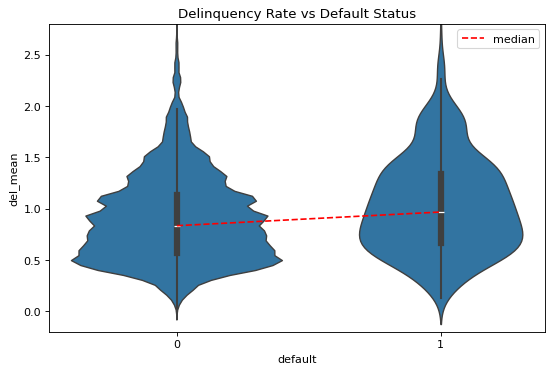

Difference in median value of delinquency mean between prepaid and defaulted loans: 0.1333


In [ ]:
# Constructing violin plot of delinquency rates by default status
X_train_y = X_train_.copy()
X_train_y['default'] = y_train
sns.violinplot(x='default', y='del_mean', data=X_train_y)
x_del=X_train_y[X_train_y['default']==0]['del_mean'].median()
y_del=X_train_y[X_train_y['default']==1]['del_mean'].median()
sns.lineplot((x_del, y_del),color='red', linestyle='--', label='median')
plt.ylim(-0.2, 2.8)
plt.title("Delinquency Rate vs Default Status")
plt.show()

print(f"Difference in median value of delinquency mean between prepaid and defaulted loans: {(y_del-x_del):.4f}")


As we can see, there is a slight increase of 0.1333 in median delinquency rate between prepaid and defaulted loans. This could indicate that the delinquency rate constructed from the `del_msa_rates` and `del_state_rates` datasets acts as some form of proxy variable, providing a degree of insight into the loan-based economic status by geographical region, although we acknowledge that further analysis would need to be performed in order to statistically come to this conclusion. In particular, factors such as the significant class imbalance of the loans' default status (only around 597 out of 101,364 loans defaulted in our training data) could mean that observations from the defaulted loans may have more "influence" on the delinquency mean distribution than for the prepaid loans.

### Interpolated Fixed-Rate Mortgage Rates

In this section, we introduce a feature called the `rate_spread`. We collect the average 30-year and 15-year weekly morgage rates from the `rates` dataset [4]. Using the `orig_loan_term` as an indicator for the loan duration, we linearly interpolate an average rate based on the 30-year rates and 15-year rates. We ensure that we use the latest available interest rate, known at the time of the orgination of the loan. Finally, we subtract this interpolated rate from the `int_rt` feature data. It is often the case that a bank will charge a client above the market rate if they are viewed as a "risky" borrower, therefore we hope that the inclusion of this `rate_spread` feature will significantly assist a model in correct loan-status classifications.

In [ ]:
# Transformer that merges interpolated fixed-rate mortgage rates into the dataset corresponding to loan origination date
class QuarterlyRatesMerger(BaseEstimator, TransformerMixin):
    def __init__(self, rates_df, merge_year_col = 'year', merge_quarter_col = 'quarter'):
        self.rates_df = rates_df
        self.merge_year_col = merge_year_col
        self.merge_quarter_col = merge_quarter_col

    def fit(self, X, y = None):
        self.sorted_rates_ = self.rates_df.copy()
        self.sorted_rates_['Week'] = pd.DatetimeIndex(self.sorted_rates_['Week'])
        self.sorted_rates_.sort_values('Week', inplace = True)
        return self

    def __interpolate_rate(self, X):
        X_ = X.copy()
        loan_term_years = X_['orig_loan_term']/12
        rate_30 = X_['30_yr_FRM'].copy()
        rate_15 = X_['15_yr_FRM'].copy()
        # gradients of interpolation line
        weight = (30 - loan_term_years)/15
        interp = weight * rate_15 + (1 - weight) * rate_30
        X_['interp_frm'] = interp
        return X_

    def __rate_spread(self, X):
        X_ = X.copy()
        X_['rate_spread'] = X_['interp_frm'] - X_['int_rt']
        return X_

    def transform(self, X, y = None):
        X_ = X.copy()
        # getitng the loan year and quarter
        first_year = X[self.merge_year_col].min()
        last_year = X[self.merge_year_col].max()
        # creating dataframe with quarter start-end dates
        quarter_starts = pd.date_range(start=f'{first_year}-01-01', end=f'{last_year + 1}-01-01', freq='QS')

        quarter_df = pd.DataFrame({'quarter_start': quarter_starts})
        quarterly_rates = pd.merge_asof(
            quarter_df,
            self.sorted_rates_,
            left_on='quarter_start',
            right_on='Week',
            direction='backward'
        )

        # Extracting the year and quarter
        quarterly_rates['year'] = quarterly_rates['quarter_start'].dt.year
        quarterly_rates['quarter'] = quarterly_rates['quarter_start'].dt.quarter

        # dropping uneccessary columns
        quarterly_rates.drop(columns=['quarter_start', 'Week'], inplace = True)
        merged_rates =  pd.merge(X_, quarterly_rates, left_on=[self.merge_year_col, self.merge_quarter_col],
                        right_on=['year', 'quarter'])
        final = self.__interpolate_rate(merged_rates)
        final = self.__rate_spread(final)
        final.drop(columns=['30_yr_FRM', '15_yr_FRM', 'interp_frm'], inplace=True)
        return final

    def get_feature_names_out(self, input_features=None):
        return list(input_features) + ['rate_spread']


In [ ]:
# Applying interest rates averages to the training data
X_train_ = QuarterlyRatesMerger(rates).fit_transform(X_train_)

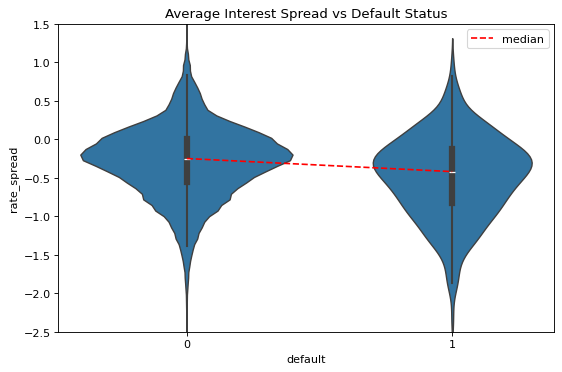

Difference in median value of average interest spread between prepaid and defaulted loans: -0.1700


In [ ]:
# Constructing violin plot of delinquency rates by default status
X_train_y = X_train_.copy()
X_train_y['default'] = y_train
sns.violinplot(x='default', y='rate_spread', data=X_train_y)
x_ir=X_train_y[X_train_y['default']==0]['rate_spread'].median()
y_ir=X_train_y[X_train_y['default']==1]['rate_spread'].median()
sns.lineplot((x_ir, y_ir),color='red', linestyle='--', label='median')
plt.ylim(-2.5, 1.5)
plt.title("Average Interest Spread vs Default Status")
plt.show()

print(f"Difference in median value of average interest spread between prepaid and defaulted loans: {(y_ir-x_ir):.4f}")


We observe that....

### Categorical Features

We now aim to gain information on each categorical feature, in particular the number of levels for each, and the total number of occurences of each level in our training data. To investigate this in a concise format, we list each category features' levels and their total number of occurences. For categorical features with larger numbers of levels, we visualise this information using histograms.

In [ ]:
# Total number of training data observations
print(f"Total number of training data observations: {len(X_train)}")
# Checking the number of unique values in categorical features
big_cats = []
for c in cat_features:
    val_counts_series = X_train[c].value_counts()
    if len(val_counts_series) <= 10:
        counts = val_counts_series.to_list()
        names = val_counts_series.index.to_list()
        print(f'{c}: {list(zip(names, counts))}')
    else:
        # Categories with larger numbers of unique values are appended for histogram plotting
        big_cats.append(c)

print(f"Categorical variables with large numbers of unique values: {big_cats}")

Total number of training data observations: 101364
flag_fthb: [('N', 79367), ('Y', 21997)]
rr_ind: [('Y', 1047)]
occpy_sts: [('P', 90115), ('I', 7333), ('S', 3916)]
prop_type: [('SF', 62316), ('PU', 29973), ('CO', 8647), ('MH', 310), ('CP', 118)]
property_val: [(2, 90085), (1, 9611), (3, 1587), (9, 81)]
loan_purpose: [('P', 57916), ('N', 22255), ('C', 21193)]
flag_sc: [('Y', 4361)]
program_ind: [('9', 93159), ('H', 7648), ('F', 557)]
Categorical variables with large numbers of unique values: ['servicer_name', 'seller_name']


As shown by these results, certain features like `rr ind`, `prop type` and `program ind` have clear imbalances in the frequency of its levels in the dataset. The large number of null and "9" entries listed for `rr ind` and `program ind` (respectively) informs us that the vast majorty of the loans in our training data are not on some sort of relief refinancing programme. `occpy sts` also has a clear categorical imbalance, with $90,115$ of $101,364$ training data loans being owner-occupied properties (P).

Next, we evaluate the categorical features with larger numbers of unique levels, `seller name` and `servicer name`. There exist duplicate errors in these features, such as `servicer name` including levels "Sterns Lending, LLC." and "Stearns Lending, LLC". There also exist particular sellers and servicers that are owned by the same company, such as "Franklin American Mortgage Company" and "Citizens Bank, N.A" being divisions of the "Citizens Financial Group".

To correct these issues, we map subsidiary and duplicate entries to their respective parent companies using a custom MapCompanyNames transformer and imported .json `companies` dictionary. This reduces feature dimensionality, fixes clear data entry errors, and may capture meaningful behavioural patterns at the company level. For consistency, we only group companies with mergers or acquisitions announced on or before 31st December 2016, in line with ensuring our model is not trained on any unseen data as of the origination data of the loan.

In [ ]:
# We import this company name dictionary from companies.json for efficiency
with open("companies.json", "r") as f:
    companies = json.load(f)

In [ ]:
# TRANSFORMER FOR CONVERTING SELLER AND SERVICER NAMES INTO COMPANY NAMES (using dictionary)
class MapCompanyNames(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def get_feature_names_out(self, input_features=None):
        return list(input_features) + ['same_seller']

    def transform(self, X):
        X_ = X.copy()
        X_['seller_name'] = X_['seller_name'].apply(lambda x: companies.get(x, x))
        X_['servicer_name'] = X_['servicer_name'].apply(lambda x: companies.get(x, x))
        X_['same_seller'] = X_.apply(lambda row: 'Y' if row['seller_name'] == row['servicer_name'] else np.nan, axis=1)
        return X_


In [ ]:
# Converting seller and servicer names using MapCompanyNames transformer
X_train_ = MapCompanyNames().fit_transform(X_train_)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(30, 8))  # 1 row, 3 columns
axes = axes.flat

# Plotting histograms for categorical features with larger numbers of unique values
for i in range(len(big_cats)):
    sns.histplot(X_train_[big_cats[i]], ax = axes[i])
    axes[i].set_title(f"Histogram plot of {big_cats[i]}")
    axes[i].tick_params(axis='x', rotation=90)

plt.show()

# Calculating how often the servicer is the same as the seller (not including Other)
filtered_data = X_train_[(X_train_['seller_name'] != "Other") & (X_train_['servicer_name'] != "Other")]
same_sel_ser_freq = filtered_data['same_seller'].value_counts().get('Y', 0) / len(filtered_data)

print(f"Rate of same seller and servicer (excluding values listed Other): {same_sel_ser_freq:.2%}")

ValueError: too many values to unpack (expected 1)

For both seller and servicer companies, our most frequent level is `Other`, indicating that our data includes many loans that are sold and serviced by companies not included on this list. This could pose as a limitation of these features' ability to provide insight into predicting the response variable, as our training data consists of 27,502 and 34,448 loans sold and serviced (respectively) by unlisted companies (as we are unaware of any information of these companies, or if any are divisions of other listed seller and servicer companies). Of our named sellers and servicers, we note that the most loans were sold and serviced by larger companies like Wells Fargo Bank, JP Morgan Chase & Co, and Rocket Companies.

Excluding seller and servicer names listed as `Other` (which may represent a wide range of companies), 73.59% of loans in our training data have the same seller and servicer. This may indicate that training a model using only one of these features could help reduce overfitting, and support feature reduction while potentially preserving a similar degree of predictive ability.

### Ordinal Features

Our dataset includes the ordinal features `cnt_borr` and `cnt_units`, which indicate the number of borrowers who are obligated to repay the mortgage and the number of units of the property, respectively. These will be feature engineered using an `OrdinalEncoder`, preserving their numerical ordering. To understand their distributions in the training set, we examine the frequency of each value in both features.

In [ ]:
# Printing the frequency of each value of cnt_borr and cnt_units
for i in ord_features:
    i_vals = X_train_[i].value_counts()
    print(f"{i} Count: {list(zip(i_vals.index.to_list(), i_vals.to_list()))}")

cnt_borr Count: [(1, 52829), (2, 47956), (3, 506), (4, 72), (5, 1)]
cnt_units Count: [(1, 99460), (2, 1347), (3, 297), (4, 260)]


From these histograms, we can see that there exists a distinct categorical imbalance for each feature, with the majority of our training data listing 1-unit properties (99,460 observations) and 1 or 2 borrowers who are obligated to repay the mortgage (100,785 observations).

These value frequences of each feature reveal clear categorical imbalances. For our training data consisting of data on $101,364$ loans, most loans in the training data are for single-unit properties (99,460 loans), and the vast majority have either one or two borrowers (100,785 loans).

### Numerical Features

We now analyse the relationships between the numerical features of our training data. When fitting models like logistic regression, it is important to ensure that our features are not highly correlated, otherwise it can make it difficult to determine the individual effect of each parameter on the response variable, which could make it difficult to interpret results. To investigate for potential correlation we construct pairplots of the data of our numerical features to assess any relationships present in the features. We also include the `del mean` and `rate spread` features, introduced by using `DelinquencyMeanAdder` and `QuarterlyRatesMerger` transformers, to further investigate these variables.

We now examine the relationships between numerical features in the training data. For models like logistic regression, it is important to avoid strong multicollinearity, as highly correlated predictors can make it difficult to isolate the individual effect of each variable on the response, complicating interpretation.

To assess potential correlations, we construct pairplots for the main numerical features. We also include two engineered features — del_mean and rate_spread — generated via the DelinquencyMeanAdder and QuarterlyRatesMerger transformers, respectively.

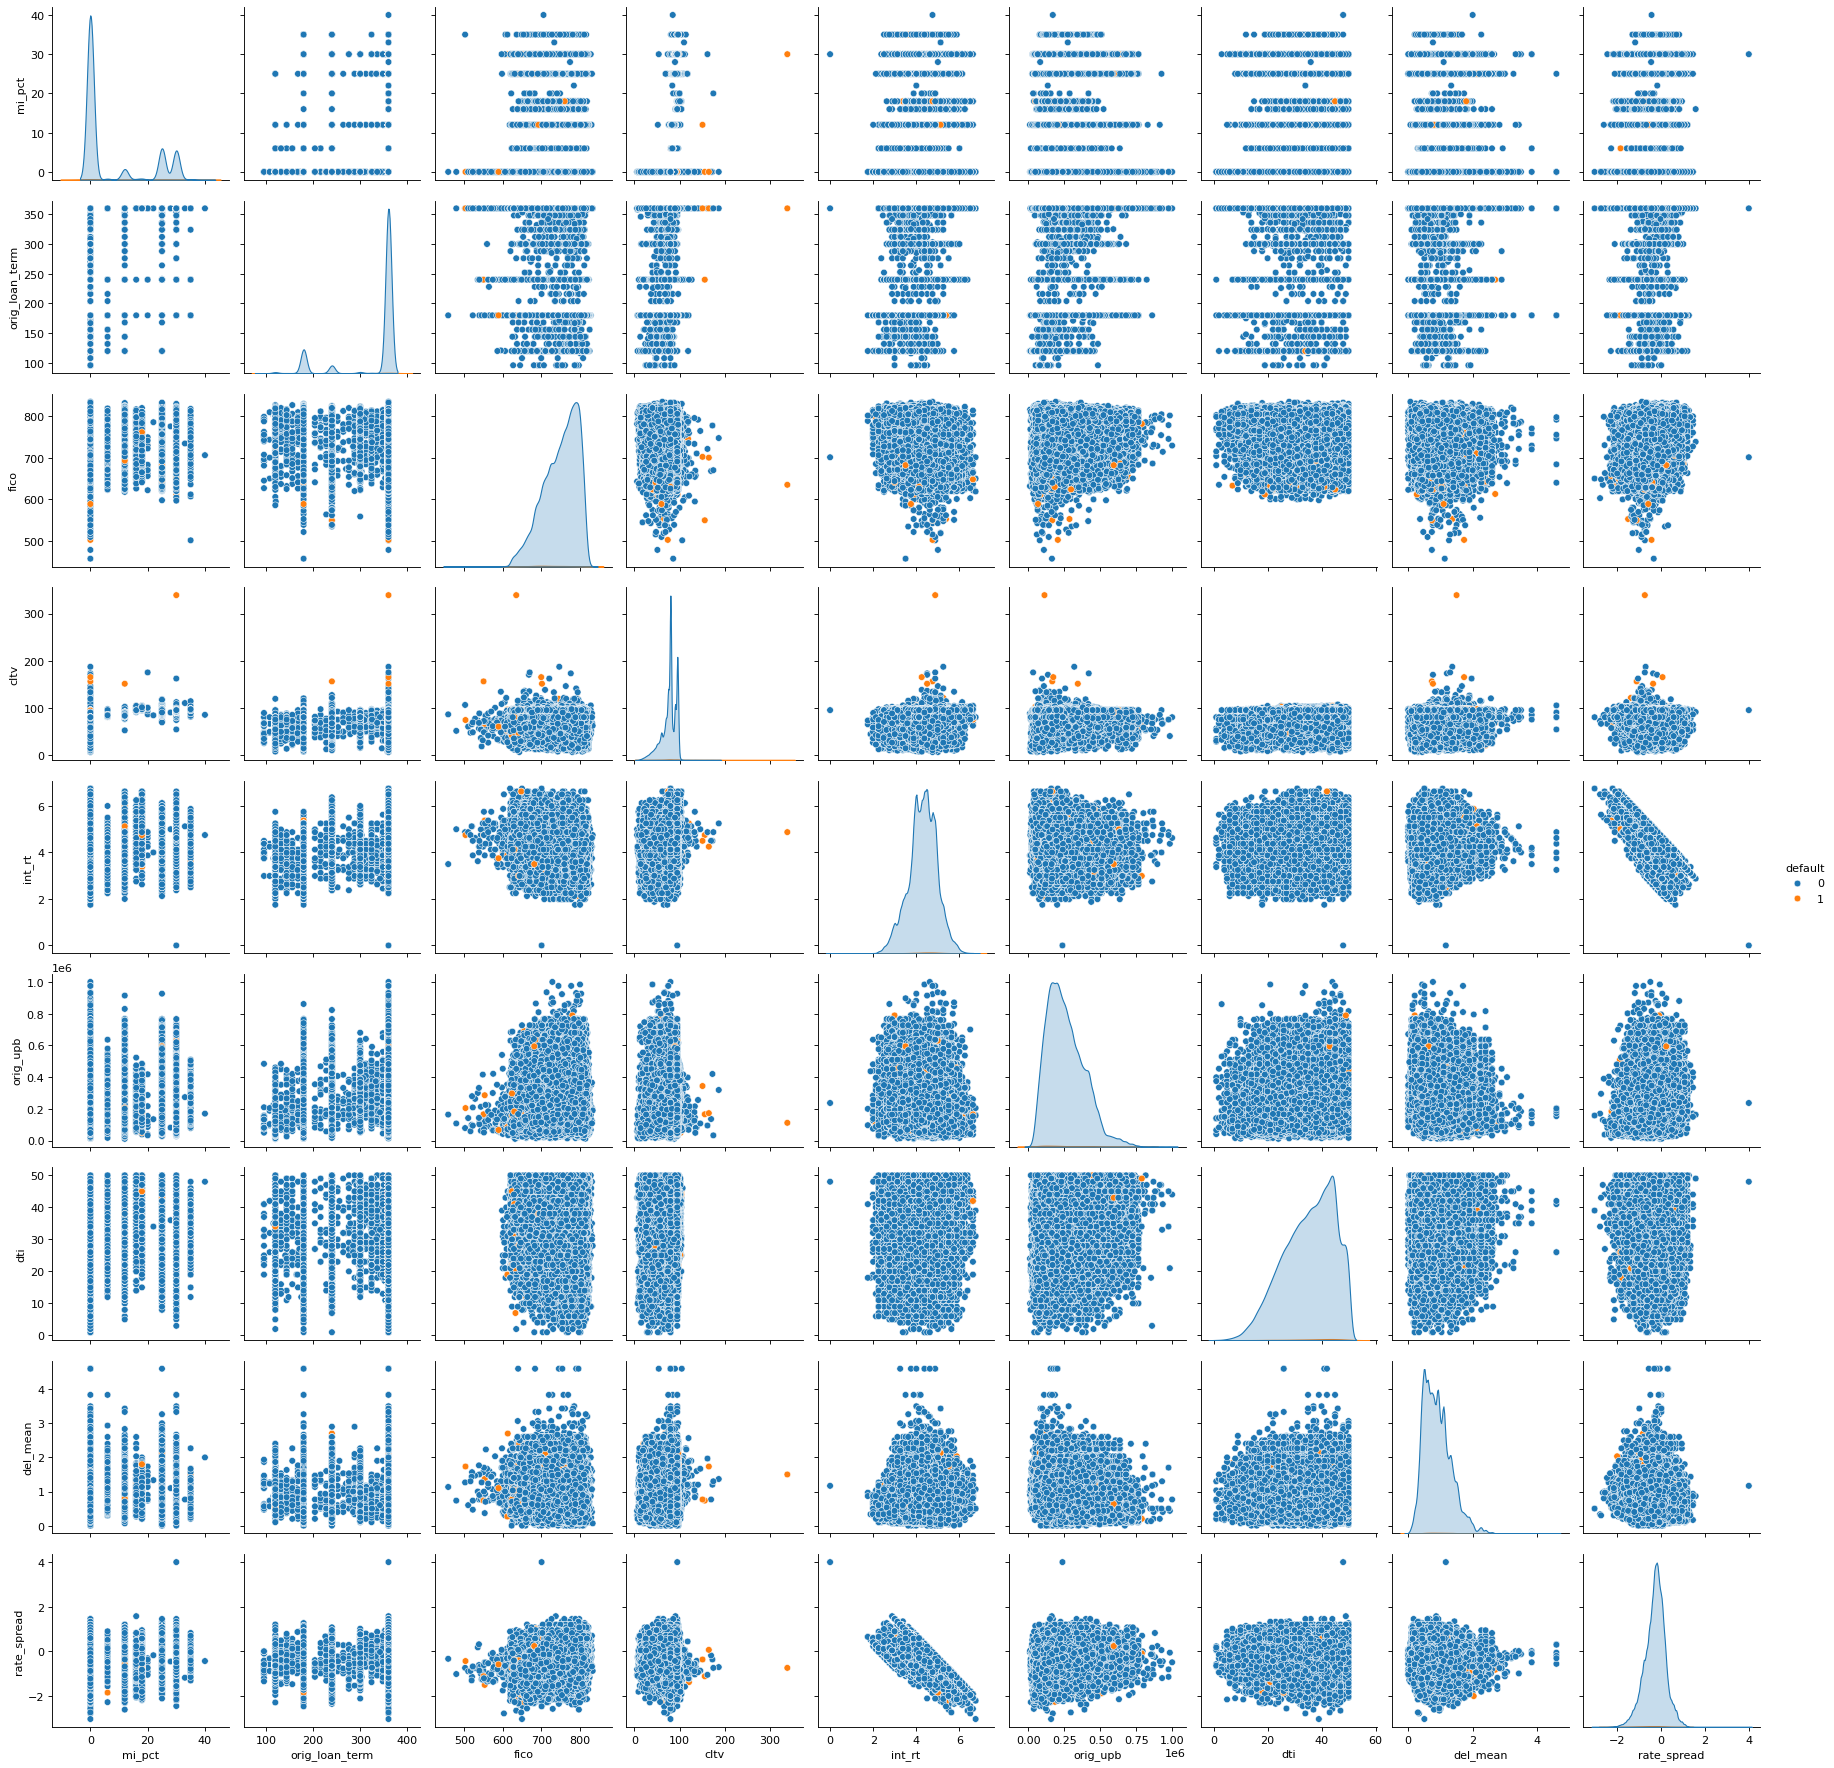

In [ ]:
fig = figsize=(20, 20)
# Pairplots of all the numerical features
X_train_num = X_train_[num_features + ['del_mean', 'rate_spread']].copy()
X_train_num_y = X_train_num.copy()
X_train_num_y['default'] = y_train
sns.pairplot(X_train_num_y, hue='default')
plt.show()

Given the class imbalance of default status, there appears to be a disproportionately high number of defaulted loans with high `cltv` (original combined loan-to-value), potentially indicating a relationship between higher cltv and higher risk of the loan defaulting. This also seems apparent for `fico` values, with the lower end of borrower's credit scores having a disproportionately high number of defaulted loans. This seems logical, given that this number is prepared by third parties as a means to assign a likehlihood that the borrower will timely repay future obligations.

Interestingly, we note that when these features are plotted against `dti`, the lower tail of `fico` data and the upper tail of `cltv` data are excluded, indicating that these data with disproportionately high default status have ratios of debt-to-income greater than 65%. This observation may suggest that including an indicator for missing `dti` may improve a model's ability to identify high-risk loans.

To further explore potential multicollinearity, we visualise the pairwise correlations between numerical features using a heatmap.

In [ ]:
# Correlation matrix of numerical features
correlations = X_train_num.corr()

# Plot heatmap
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

NameError: name 'X_train_num' is not defined

As seen in the correlation matrix, most numerical features are not strongly correlated. However, there are a few notable exceptions that must be considered.There existd a strong positive correlation of $0.66$ between `mi pct` and `cltv`, indicating that loans with higher combined loan-to-value may also have higher mortgage insurance of loss coverage on the loan. This seems logical, given that a higher cltv implies the borrower has a greater proportion of debt secured by their home, potentially leading to higher risk for lenders, which would suggest that the loss coverage would therefore be calculated to be higher.

Additionally, there is a strong negative correlation of $0.69$ between `int rt` and `rate spread`, logical given both metrics measure interest rates for particular loans, and that `rate spread` is calculated by subtracting the loan interest rate from from the interpolated interest rates. This correlation is significantly high however, and may indicate that a logistic regression model would be more interpretable when only using one of these two features.

# Model Fitting and Tuning

## Baseline Model

We start by fitting a baseline model which we will be able to use as a point of comparison for our subsequent model. We fit a logistic regression model as follows. We preprocess the numerical features: `'fico`, `mi_pct`, `cltv`, `orig_upb`, `int_rt`, `dti`, by (1) imputing the missing data using the mean of the feature, (2) Scale the feature to have mean $0$ and standard deviation 1. Furthmore, we add an dummy variable indicating that `dti` is missing for that observation. Moving onto the categorical variables, we begin by Imputing missing values for `flag_fthb`, `flag_sc`, `loan_purpose`, `occpy_sts`, `prop_type`, `program_ind`, `rr_ind`, `property_val`, `same_seller`, `servicer_name` using the most frequent observation in each case followed by `OneHotEncoder`,  `program_ind` is not imputed but rather `OneHotEncoder` is directly applied. Finally, we include ordinal variables `cnt_borr`, `cnt_units` - without further preprocessingWe start by fitting a baseline model which we shall use as a point of comparison for our subsequent model. In particular, we aim to fit a simple logistic regression model that includes all features discussed in our exploratory data analysis. To mitigate data errors, we shall use the `MapCompanyNames` transformer to ensure consistency between seller and servicer names in our dataset.

To transform our data into suitable formatting to be using in a logistic regession model, we use the preprocessing techniques detailed below. Namely; we use particular transformations to sort missing data, OneHotEncoding is applied to the categorical variables and numerical variables are standardly scaled. In fitting our logistic regression model on the training data, we balance class weights to ensure our response data is equally balanced between default and prepaid data.

In [ ]:
flags = {'flag_sc': np.nan, 'rr_ind': np.nan, 'same_seller': np.nan}


# Original feature groups:
cat_features = ['flag_fthb', 'flag_sc', 'loan_purpose', 'occpy_sts', 'prop_type', 'program_ind', 'rr_ind', 'property_val', 'same_seller', 'servicer_name']
#cat_features = ['prop_type', 'program_ind', 'rr_ind', 'property_val']
numerical_features = ['fico', 'mi_pct', 'dti', 'cltv', 'orig_upb', 'int_rt']
ordinal_features = ['cnt_borr', 'cnt_units']

feat_diff = lambda feature_list, features_subtract: list(set(feature_list).difference(set(features_subtract)))

num_pre = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Feature union for dti so we do not scale indicator with StandardScaler
num_pre_censored = FeatureUnion([
    ('num_pre', num_pre),
    ('indicator', MissingIndicator())
])

cat_impute_before_encode = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False))
])

cat_encode_missing = Pipeline([
    ('encoder', OneHotEncoder(sparse_output = False))
])

# Identity transformer: it just returns X as is - ordinal
class IdentityTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self
    def transform(self, X):
        return X
    def get_feature_names_out(self, input_features=None):
        return list(input_features)


preprocessor = ColumnTransformer([
    ('num_pre_uncensored', num_pre, feat_diff(num_features, ['dti'])),
    ('num_pre_censored', num_pre_censored, ['dti']),
    ('cat_pre_imputer_first', cat_impute_before_encode, feat_diff(cat_features, ['program_ind'])),
    ('cat_pre_encoder_missing', cat_encode_missing, ['program_ind']),
    ('ord_pre', IdentityTransformer(), ordinal_features)
], remainder='drop')

# no ordinal transformations required, ordinal feautues are all there, and already in order
# Logistic Regression Model pipeline
bl_pipeline = Pipeline([
    ('map_company_names', MapCompanyNames()),
    ('fill_flag_vars', UnifyMissing(flags, fill_value='N')), # turn all flag missing to N
    ('unify_missing', UnifyMissing(missing_codes)), # Turn all missing variables to nan
    ('pre', preprocessor),
    ('est', LogisticRegression(class_weight='balanced', max_iter=1000))
])


We will now fit the baseline model with the described preprocessing steps, and firstly, plot a confusion matrix followed by printing a classification summary which includes classification peformance metrics such as precision, recall and f1-score for both classes.

In [ ]:
# Fitting the baseline model
bl_model = bl_pipeline.fit(X_train, y_train)

In [ ]:
bl_pred = bl_model.predict(X_test)
print(classification_report(y_test, bl_pred))

              precision    recall  f1-score   support

           0       1.00      0.74      0.85     25192
           1       0.02      0.72      0.03       149

    accuracy                           0.74     25341
   macro avg       0.51      0.73      0.44     25341
weighted avg       0.99      0.74      0.84     25341



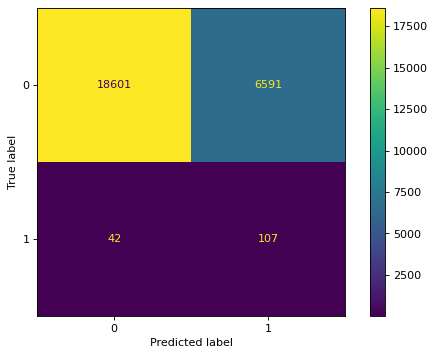

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, bl_pred)
plt.show()

## Model Description

In search of finding a suitable model, we tried Random Forests and Support Vector Machines with the same pre-processing steps as the baseline model used. However, upon analysing their confusion matrices, we found them to severely underperform in identifying mortgages which will default.


There are possibly many complex interactions of variables in our dataset. High interest rates coupled with a high loan to value ratio could create a more burdensome monthly payment, which could correlate with higher default risk to name one. In aim of capturing rich relationships and interactions we proceed with a neural-network-type estimator. The model takes a variable input of $n$ features and feeds them into the hidden layers, the number and the size of which will be tuned in the following section. Furthermore, each dense layer uses a ReLU activation to create nonlinearity and $l_2$ regularization to mitigate overfitting, the strength of which will also be tuned in the next section. Batch Normalization is applied after each dense layer to stabilize training and finally a dropout rate of $q$ (which randomly sets a fraction of the neuron's activations to $0$) is applied to help reduce overfitting the training data. Finally, a sigmoid activation is applied to model the probability that a mortgage will default. The model neural network architecture is detailed in the cell below, along with a custom keras wrapper so that it is compatible with `sklearn's` API.

In [ ]:
# 1. scikeras does not work properly because it raises error regarding sklearn tags
# 2. keras.wrappers.SKLearnClassifier does not have predict_proba
# 3. So we build our own wrapper
class KerasModelWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, build_fn, build_params={}, fit_params={}):
        self.build_fn = build_fn
        self.build_params = build_params
        self.fit_params = fit_params
        self.model_ = None

    def fit(self, X, y):
        self.model_ = self.build_fn(X, y, **self.build_params)
        self.model_.fit(X, y, **self.fit_params)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        probs = self.model_.predict(X)
        return (probs > 0.5).astype("int32").ravel()

    def predict_proba(self, X):
        preds =  self.model_.predict(X)
        preds = np.hstack([1 - preds, preds])
        return preds

    def get_params(self, deep=True):
        return {
            "build_fn": self.build_fn,
            "build_params": self.build_params,
            "fit_params": self.fit_params,
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


def dynamic_model(X, y, loss, layers=[64, 32], dropout_rate=0.3, l2_reg=0.001):
    n_features_in = X.shape[1]
    inp = Input(shape=(n_features_in,))
    hidden = inp
    for layer_size in layers:
        hidden = Dense(layer_size, activation="relu",
                       kernel_regularizer=regularizers.l2(l2_reg)
                      )(hidden)
        hidden = BatchNormalization()(hidden)
        hidden = Dropout(dropout_rate)(hidden)

    out = Dense(1, activation="sigmoid")(hidden)

    model = Model(inp, out)
    model.compile(loss=loss, optimizer=Adam(learning_rate=0.0001))
    return model


## Model Tuning

We will first discuss some hyperparameters which we keep constant throughout of our tuning process. We fit the model, optimising the binary cross entropy loss, using the Adam optimizer wih a learning rate of $1e-4$. We found the Adam optimizer to yield stable convergence. Furthermore, for each experiment, we employ a batch-size of $512$ for a total of 40 epochs. We stop the training process if the validation loss (a separate $20 \%$ of the training data) has not improved for $4$ consecutive epochs to further prevent overfitting. As briefly mentioned, we will tune the dropout rate, $l_2$ regularization, and the number and size of the hidden layers, using grid search, evaluating each hyper-parameter combination with $3$-fold procedure, which monitors the $f_1$-score. The parameter grid we use can be seen in the following cell.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=4, verbose=1)

nn_estimator = KerasModelWrapper(
    build_fn=dynamic_model,
    build_params={
        "loss": 'binary_crossentropy',
        "layers":  [64, 32],
        "dropout_rate": 0.2,
        "l2_reg": 0.1,
    },
    fit_params={
        "epochs": 30,
        "batch_size": 512 ,
        "validation_split": 0.2,
        "verbose": 1,
        "shuffle": True,
        "callbacks": [early_stopping],
    }
)

param_grid = {
    "model__model_kwargs__dropout_rate": [0, 0.2, 0.3, 0.4],
    "model__model_kwargs__l2_reg": [0.0001, 0.001, 0.01, 0.1],
    "model__model_kwargs__layers": [[128, 64, 32], [64, 8]]
}


We perform all the feature engineering and preprocessing steps as described in our baseline logistic regression model, additionally introducing the interest rate spread, mean delinquency rates, and a binary variable (`TRUE` or `FALSE`) for territory.

In [ ]:
nn_model_numerical_features = num_features + ['rate_spread', 'del_mean']
nn_model_cat_features = cat_features + ['territory']

preprocessor = ColumnTransformer([
    ('num_pre', num_pre, num_features),
    ('cat_pre_imputer_first', cat_impute_before_encode, list(set(cat_features).difference({'program_ind'}))),
    ('cat_pre_encoder_missing', cat_encode_missing, ['program_ind']),
    ('ord_pre', IdentityTransformer(), ord_features)
], remainder='drop')

# no ordinal transformations required, ordinal feautues are all there, and already in order
nn_pipeline = Pipeline([
    ('map_company_names', MapCompanyNames()),
    ('fill_flag_vars', UnifyMissing(flags, fill_value='N')), # turn all flag missing to N
    ('unify_missing', UnifyMissing(missing_codes)), # Turn all missing variables to nan
    ('decode_id', LoanIDDecoder()),
    ('add_rate_spread', QuarterlyRatesMerger(rates)),
    ('add_del_mean', DeliquencyMeanAdder(del_msa_rates, del_state_rates)),
    ('pre', preprocessor),
    ('sampler', RandomOverSampler()),
    ('model', nn_estimator)
])

We peform the $3$ - fold validation mentioned in the following cell

In [ ]:
grid = RandomizedSearchCV(nn_pipeline, param_grid, n_iter = 10, cv = 3, scoring="average_precision", verbose=1, random_state=rng)
grid.fit(X_train, y_train)

In [50]:
# View the best average precision score
print("Best AP score:", grid.best_score_)

# View the best parameters
print("Best parameters:", grid.best_params_)

# Retrieve the best estimator
final_model = grid.best_estimator_

Best AP score: 0.04408104823172823
Best parameters: {'model__model_kwargs__layers': [64, 8], 'model__model_kwargs__l2_reg': 0.001, 'model__model_kwargs__dropout_rate': 0.4}


In [60]:
best_params = {'model__model_kwargs__layers': [64, 8],
               'model__model_kwargs__l2_reg': 0.001,
               'model__model_kwargs__dropout_rate': 0.4}

final_model.set_params(**best_params)
final_model.fit(X_train, y_train)

In [61]:
pred = final_model.predict(X_test)

792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


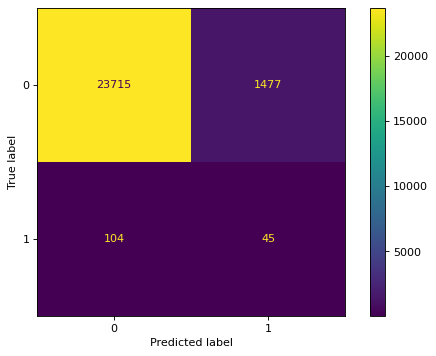

In [62]:
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)

In [63]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     25192
           1       0.03      0.30      0.05       149

    accuracy                           0.94     25341
   macro avg       0.51      0.62      0.51     25341
weighted avg       0.99      0.94      0.96     25341



## Comparison with the baseline model

As we can see from the confusion matrices and classification summaries, logistic regression appears to correctly identify more loans which will default, howevever in the process, incorrectly classifies many more loans to default. That said, the probability threshold can easily be chosen as to missclassify more loans to be paid-off in our final model. Furthermore, the weighted average precision, recall, and f1-score has improved in our model, when compared to the baseline. We will analyse the most important features in predicting morgage default

In [ ]:
f1_scorer = make_scorer(f1_score, average='binary')
results = permutation_importance(final_model, X_test, y_test, n_repeats=3, random_state=rng, scoring=f1_scorer)

In [71]:
sorted_importances_idx  = results.importances_mean.argsort()
test_importances = pd.DataFrame(
    results.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx],
)

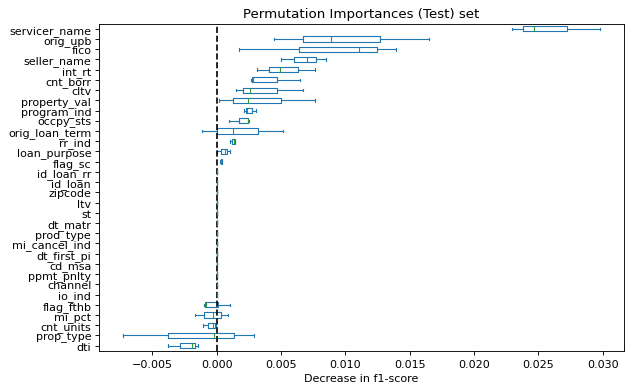

In [73]:
ax = test_importances.plot.box(vert=False, whis=10)
ax.set_title(f"Permutation Importances (Test) set")
ax.set_xlabel("Decrease in f1-score")
ax.axvline(x=0, color="k", linestyle="--")
ax.figure.tight_layout()

In [75]:
from sklearn.inspection import PartialDependenceDisplay

In [76]:
PartialDependenceDisplay.from_estimator(
    estimator=final_model,
    X=X,
    features=['servicer_name', 'orig_upb'],
    kind='average',  # 'average' means partial dependence
    ax=ax
)

3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3960/3960 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


KeyboardInterrupt: 

# Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a banking official, who is understands the issues associated with mortgage defaults but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of default, which may be useful for the companies to improve their understanding of
mortgage defaults, and also to explain their decisions to clients and regulatory bodies. You should also use your model to inform the company of any active loans that are at risk of default.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explinations / justifications.*

## Discussions of Results

In this project, we developed a baseline predictive model using Logistic Regression and a second predictive model using neural networks. These approaches both proved to provide insight into how particular economical, geographical and social factors can be utilised in predicting whether various loans will default.

## Identifying high-risk active loans


Using our neural network, we produce prediction probabilities of each active loan defaulting. Active loans were classified as high-risk if our neural network model assigned them a probability of greater than 80%.

In [ ]:
# Extracting our active loan data
X_active = d_active[features].copy()
# Using our final model on active loan data
fm_pred_probs = final_model.predict_proba(X_active)
# Identifying high-risk active loans
fm_hr_al = X_active[fm_pred_probs[:,1]>0.8]
fm_non_hr_al = X_active[fm_pred_probs[:,1]<=0.8]
X_active[fm_pred_probs].head()

NameError: name 'final_model' is not defined

Our neural network identifies 2,437 of our 73,295 active loans (3.32% of active loans) to be at high risk (probability greater than 80%).

In [ ]:
print(f"Number of Active Loans classified as high risk: {len(fm_hr_al)}")
print(f"Percentage of Active Loans classified as high risk: {len(fm_hr_al)/len(X_active)*100 :.2f}%")

NameError: name 'fm_hr_al' is not defined

We note that our neural network assigns very low probability of defaulting to the vast majority of our active loans, forming a heavily skewed distribution.

## Final Conclusions

# Generative AI statement

In this report, Generative AI (in particular, ChatGPT, DeepSeek V3 and VS Code Copilot) were used for debugging code, and to provide hints and suggestions to improve code and enhance visualisation plots.

# References

[1]. Freddie Mac, Single Family Loan-Level Dataset. URL: www.freddiemac.com/research/datasets/sf-loanlevel-dataset (visited on 02/04/2025).

[2]. Consumer Financial Protection Bureau, Mortgages 90 or More Days Delinquent (Metro and non-metro areas). URL: https://www.consumerfinance.gov/data-research/mortgage-performance-trends/download-the-data/ (visited on 03/04/2025).

[3]. Consumer Financial Protection Bureau, Mortgages 90 or More Days Delinquent (States). URL: https://www.consumerfinance.gov/data-research/mortgage-performance-trends/download-the-data/ (visited on 03/04/2025).

[4]. Primary Mortgage Market Survey. URL: https://www.freddiemac.com/

[5]. Batch Normalization: Accelerating Deep Network Training Reducing Internal Covariate Shift. URL: https://arxiv.org/pdf/1502.03167

In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project2.ipynb